# Inference on custom images

## Download code and install dependencies

In [ ]:
!git clone https://github.com/j-min/CLIP-Caption-Reward

Cloning into 'CLIP-Caption-Reward'...
remote: Enumerating objects: 162, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 162 (delta 19), reused 21 (delta 16), pack-reused 128 (from 1)
Receiving objects: 100% (162/162), 2.71 MiB | 22.20 MiB/s, done.
Resolving deltas: 100% (52/52), done.


In [ ]:
cd /content/CLIP-Caption-Reward

/content/CLIP-Caption-Reward


In [ ]:
!pip install -r requirements.txt
!pip uninstall -y  torchtext # to bypass pt-lightning issue (https://github.com/PyTorchLightning/pytorch-lightning/issues/6415)
!pip install -e .

Obtaining file:///content/CLIP-Caption-Reward
  Preparing metadata (setup.py) ... done
  Attempting uninstall: captioning
    Found existing installation: captioning 0.0.1
    Uninstalling captioning-0.0.1:
      Successfully uninstalled captioning-0.0.1
  Running setup.py develop for captioning


# Import packages

In [ ]:
import torch
import torch.nn as nn

import numpy as np

import json

import captioning.utils.opts as opts
import captioning.models as models
import captioning.utils.misc as utils

import pytorch_lightning as pl

# Checkpoint class
class ModelCheckpoint(pl.callbacks.ModelCheckpoint):

    def on_keyboard_interrupt(self, trainer, pl_module):
        # Save model when keyboard interrupt
        filepath = os.path.join(self.dirpath, self.prefix + 'interrupt.ckpt')
        self._save_model(filepath)

# Device and model configurations

In [ ]:
device = 'cpu' #@param ["cuda", "cpu"] {allow-input: true}

reward = 'clips_grammar' #@param ["mle", "cider", "clips", "cider_clips", "clips_grammar"] {allow-input: true}

if reward == 'mle':
    cfg = f'./configs/phase1/clipRN50_{reward}.yml'
else:
    cfg = f'./configs/phase2/clipRN50_{reward}.yml'

print("Loading cfg from", cfg)

opt = opts.parse_opt(parse=False, cfg=cfg)

Loading cfg from ./configs/phase2/clipRN50_clips_grammar.yml


# Download pretrained checkpoint

In [ ]:
import gdown

In [ ]:
if reward == "mle":
  url = "https://drive.google.com/drive/folders/1hfHWDn5iXsdjB63E5zdZBAoRLWHQC3LD"
elif reward == "cider":
  url = "https://drive.google.com/drive/folders/1MnSmCd8HFnBvQq_4K-q4vsVkzEw0OIOs"
elif reward == "clips":
  url = "https://drive.google.com/drive/folders/1toceycN-qilHsbYjKalBLtHJck1acQVe"
elif reward == "cider_clips":
  url = "https://drive.google.com/drive/folders/1toceycN-qilHsbYjKalBLtHJck1acQVe"
elif reward == "clips_grammar":
  url = "https://drive.google.com/drive/folders/1nSX9aS7pPK4-OTHYtsUD_uEkwIQVIV7W"
gdown.download_folder(url, quiet=True, use_cookies=False, output="save/")

['save/clipRN50_clips_grammar/clipRN50_clips_grammar-last.ckpt']

# Load vocabulary

In [ ]:
url = "https://drive.google.com/uc?id=1HNRE1MYO9wxmtMHLC8zURraoNFu157Dp"
gdown.download(url, quiet=True, use_cookies=False, output="data/")

'data/cocotalk.json'

In [ ]:
dict_json = json.load(open('./data/cocotalk.json'))
print(dict_json.keys())

ix_to_word = dict_json['ix_to_word']
vocab_size = len(ix_to_word)
print('vocab size:', vocab_size)

seq_length = 1

opt.vocab_size = vocab_size
opt.seq_length = seq_length

dict_keys(['ix_to_word', 'images'])
vocab size: 9487


In [ ]:
# #optimize
# epochs = 10  #@param {type:"integer"}
# learning_rate = 1e-4  #@param {type:"number"}
# batch_size = 32  #@param {type:"integer"}

# # Define the optimizer and learning rate scheduler
# optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.95)

# # Define the loss function
# criterion = nn.CrossEntropyLoss()

# # Train the model
# for epoch in range(epochs):
#   model.train()
#   total_loss = 0
#   for batch_idx, (data, target) in enumerate(train_loader):
#     data, target = data.to(device), target.to(device)
#     optimizer.zero_grad()
#     output = model(data)
#     loss = criterion(output, target)
#     loss.backward()
#     optimizer.step()
#     total_loss += loss.item()
#   print(f'Epoch [{epoch+1}/{epochs}], Loss: {total_loss / len(train_loader):.4f}')
#   scheduler.step()

# # Save the finetuned model
# torch.save(model.state_dict(), 'finetuned_model.pth')

# Load Model checkpoint

In [ ]:
opt.batch_size = 1
opt.vocab = ix_to_word
# opt.use_grammar = False

model = models.setup(opt)
del opt.vocab

ckpt_path = opt.checkpoint_path + '-last.ckpt'

print("Loading checkpoint from", ckpt_path)
raw_state_dict = torch.load(
    ckpt_path,
    map_location=device)

strict = True

state_dict = raw_state_dict['state_dict']

if '_vocab' in state_dict:
    model.vocab = utils.deserialize(state_dict['_vocab'])
    del state_dict['_vocab']
elif strict:
    raise KeyError
if '_opt' in state_dict:
    saved_model_opt = utils.deserialize(state_dict['_opt'])
    del state_dict['_opt']
    # Make sure the saved opt is compatible with the curren topt
    need_be_same = ["caption_model",
                    "rnn_type", "rnn_size", "num_layers"]
    for checkme in need_be_same:
        if getattr(saved_model_opt, checkme) in ['updown', 'topdown'] and \
                getattr(opt, checkme) in ['updown', 'topdown']:
            continue
        assert getattr(saved_model_opt, checkme) == getattr(
            opt, checkme), "Command line argument and saved model disagree on '%s' " % checkme
elif strict:
    raise KeyError
res = model.load_state_dict(state_dict, strict)
print(res)

model = model.to(device)
model.eval();

Loading checkpoint from save/clipRN50_clips_grammar/clipRN50_clips_grammar-last.ckpt


<ipython-input-30-4a52649d3c31>:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  raw_state_dict = torch.load(


<All keys matched successfully>


# Load CLIP image encoder

In [ ]:
import clip
from torchvision.transforms import Compose, Resize, CenterCrop, ToTensor, Normalize
from PIL import Image
from timm.models.vision_transformer import resize_pos_embed

clip_model, clip_transform = clip.load("RN50", jit=False, device=device)

preprocess = Compose([
    Resize((448, 448), interpolation=Image.BICUBIC),
    CenterCrop((448, 448)),
    ToTensor()
])

image_mean = torch.Tensor([0.48145466, 0.4578275, 0.40821073]).to(device).reshape(3, 1, 1)
image_std = torch.Tensor([0.26862954, 0.26130258, 0.27577711]).to(device).reshape(3, 1, 1)

num_patches = 196 #600 * 1000 // 32 // 32
pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, clip_model.visual.attnpool.positional_embedding.shape[-1],  device=device),)
pos_embed.weight = resize_pos_embed(clip_model.visual.attnpool.positional_embedding.unsqueeze(0), pos_embed)
clip_model.visual.attnpool.positional_embedding = pos_embed

# Getting Images from MS-COCO Dataset

In [ ]:
# # Step 1: Install pycocotools for working with the MS COCO dataset
# !pip install pycocotools
# import zipfile
# import os
# import urllib.request

# # Step 2: Import necessary libraries
# import matplotlib.pyplot as plt
# from pycocotools.coco import COCO
# import requests
# from PIL import Image
# from io import BytesIO

# # Step 3: Define the paths for images and annotations
# coco_annotation_url = 'http://images.cocodataset.org/annotations/annotations_trainval2017.zip'
# coco_image_url = 'http://images.cocodataset.org/zips/train2017.zip'

# # Download annotations
# if not os.path.exists('annotations_trainval2017.zip'):
#     print("Downloading annotations...")
#     urllib.request.urlretrieve(coco_annotation_url, 'annotations_trainval2017.zip')
#     with zipfile.ZipFile('annotations_trainval2017.zip', 'r') as zip_ref:
#         zip_ref.extractall()

# # Step 4: Load COCO annotations
# dataDir = ''
# dataType = 'train2017'
# annFile = f'annotations/captions_{dataType}.json'
# coco = COCO(annFile)

# # Step 5: Get image IDs and captions for a sample of 50 images
# image_ids = coco.getImgIds()
# selected_ids = image_ids[:500]  # Select the first 50 images (you can randomize or filter as needed)

# # Step 6: Initialize lists to store images, file names, paths, and captions
# images_list = []
# file_names_list = []
# file_paths_list = []
# captions_list = []

# # Step 7: Create a directory to save images
# save_dir = 'coco_images'
# if not os.path.exists(save_dir):
#     os.makedirs(save_dir)

# # Step 8: Download images, save them, and store paths
# for img_id in selected_ids:
#     img_info = coco.loadImgs(img_id)[0]
#     img_url = img_info['coco_url']
#     file_name = img_info['file_name']
#     file_path = os.path.join(save_dir, file_name)

#     # Download and open image
#     response = requests.get(img_url)
#     img = Image.open(BytesIO(response.content))

#     # Save image to the directory
#     img.save(file_path)

#     # Append image, file name, file path, and caption to lists
#     images_list.append(img)
#     file_names_list.append(file_name)
#     file_paths_list.append(file_path)

#     # Get caption
#     ann_ids = coco.getAnnIds(imgIds=img_info['id'])
#     anns = coco.loadAnns(ann_ids)

#     # Store captions in list
#     captions_list.append(anns[0]['caption'])  # Store first caption (you can store more if needed)



# Step 1: Install pycocotools for working with the MS COCO dataset
!pip install pycocotools
import zipfile
import os
import urllib.request

# Step 2: Import necessary libraries
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
import requests
from PIL import Image
from io import BytesIO

# Step 3: Define the paths for images and annotations
coco_annotation_url = 'http://images.cocodataset.org/annotations/annotations_trainval2017.zip'
coco_image_url = 'http://images.cocodataset.org/zips/train2017.zip'

# Download annotations if not already downloaded
if not os.path.exists('annotations_trainval2017.zip'):
    print("Downloading annotations...")
    urllib.request.urlretrieve(coco_annotation_url, 'annotations_trainval2017.zip')
    with zipfile.ZipFile('annotations_trainval2017.zip', 'r') as zip_ref:
        zip_ref.extractall()

# Step 4: Load COCO annotations
dataDir = ''
dataType = 'train2017'
annFile = f'annotations/captions_{dataType}.json'
coco = COCO(annFile)

# Step 5: Get image IDs and captions for a sample of 500 images
image_ids = coco.getImgIds()
selected_ids = image_ids[:500]  # Select the first 500 images

# Step 6: Initialize lists to store images, file names, paths, and captions
images_list = []
file_names_list = []
file_paths_list = []
captions_list = []

# Step 7: Create a directory to save images
save_dir = 'coco_images'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Step 8: Download images, save them, and store paths
for img_id in selected_ids:
    img_info = coco.loadImgs(img_id)[0]
    img_url = img_info['coco_url']
    file_name = img_info['file_name']
    file_path = os.path.join(save_dir, file_name)

    # Download and open image
    response = requests.get(img_url)
    img = Image.open(BytesIO(response.content))

    # Save image to the directory
    img.save(file_path)

    # Append image, file name, file path, and captions to lists
    images_list.append(img)
    file_names_list.append(file_name)
    file_paths_list.append(file_path)

    # Get annotations and store captions
    ann_ids = coco.getAnnIds(imgIds=img_info['id'])
    anns = coco.loadAnns(ann_ids)
    if anns:
        captions_list.append(anns[0]['caption'])  # Store the first caption for each image
    else:
        captions_list.append("No caption available")  # Handle case with no captions

print("Downloaded 500 images and their captions successfully.")








loading annotations into memory...
Done (t=3.50s)
creating index...
index created!
Downloaded 500 images and their captions successfully.


# Prediciting Captions of Test Images

In [ ]:
import numpy as np

# Create an empty 2D array with dimensions 3x3 for storing strings
generated_captions = np.empty((500), dtype=object)




for i, (file_name, file_path, caption) in enumerate(zip(file_names_list, file_paths_list, captions_list)):
  #Load image from saved path
    img = Image.open(file_path)

    # Display the image
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Caption: {caption}")
    plt.show()


    print(f"Image {i+1}:")
    # print(f"File Name: {file_name}")
    # print(f"File Path: {file_path}")
    print(f"Caption: {caption}\n")
    img_path = file_path
    from IPython.display import Image as show_image
    show_image(img_path)
    with torch.no_grad():
      image = preprocess(Image.open( img_path ).convert("RGB"))
      image = torch.tensor(np.stack([image])).to(device)
      image -= image_mean
      image /= image_std

      tmp_att, tmp_fc = clip_model.encode_image(image)
      tmp_att = tmp_att[0].permute(1, 2, 0)
      tmp_fc = tmp_fc[0]

      att_feat = tmp_att
      fc_feat = tmp_fc
      eval_kwargs = {}
      eval_kwargs.update(vars(opt))

      verbose = eval_kwargs.get('verbose', True)
      verbose_beam = eval_kwargs.get('verbose_beam', 0)
      verbose_loss = eval_kwargs.get('verbose_loss', 1)

      # dataset = eval_kwargs.get('dataset', 'coco')
      beam_size = eval_kwargs.get('beam_size', 1)
      sample_n = eval_kwargs.get('sample_n', 1)
      remove_bad_endings = eval_kwargs.get('remove_bad_endings', 0)

      with torch.no_grad():
          fc_feats = torch.zeros((1,0)).to(device)
          att_feats = att_feat.view(1, 196, 2048).float().to(device)
          att_masks = None

          # forward the model to also get generated samples for each image
          # Only leave one feature for each image, in case duplicate sample
          tmp_eval_kwargs = eval_kwargs.copy()
          tmp_eval_kwargs.update({'sample_n': 1})
          seq, seq_logprobs = model(fc_feats, att_feats, att_masks)
          seq = seq.data

          sents = utils.decode_sequence(model.vocab, seq)
      generated_captions[i] = sents
      print(generated_captions[i])

# Calculating Similarities of Captions using One Hot Encoding

In [ ]:
# import numpy as np
# from sklearn.preprocessing import LabelBinarizer
# from sklearn.metrics.pairwise import cosine_similarity

# def one_hot_encode_captions(captions):
#     # Tokenize the captions
#     tokens = [caption.lower().split() if isinstance(caption, str) else [str(item).lower().split() for item in caption] for caption in captions]

#     # Flatten the tokens list to create a unique vocabulary
#     vocab = sorted(set([token for sublist in tokens for token in sublist]))

#     # Initialize the LabelBinarizer to perform one-hot encoding
#     lb = LabelBinarizer()
#     lb.fit(vocab)

#     # One-hot encode each caption
#     one_hot_encoded = [lb.transform(caption.split()).sum(axis=0) if isinstance(caption, str) else lb.transform([str(item) for item in caption]).sum(axis=0) for caption in captions]

#     return one_hot_encoded, vocab

# def compare_captions(caption1, caption2):
#     captions = [caption1, caption2]
#     one_hot_encoded, vocab = one_hot_encode_captions(captions)

#     # Calculate cosine similarity between two one-hot encoded captions
#     similarity = cosine_similarity([one_hot_encoded[0]], [one_hot_encoded[1]])[0][0]

#     return similarity, one_hot_encoded, vocab



import numpy as np
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity

def one_hot_encode_captions(captions):
    # Tokenize the captions, handle string, list of strings and list of lists of strings
    tokens = []
    for caption in captions:
        if isinstance(caption, str):
            tokens.append(caption.lower().split())  # Wrap in a list for consistency
        elif isinstance(caption, list):
            # Assuming caption is a list of strings (single generated caption)
            tokens.append([token.lower() for token in caption[0].split() if token]) # Handle empty tokens
        else:
            raise ValueError(f"Unsupported caption type: {type(caption)}")

    # Flatten the tokens list to create a unique vocabulary
    vocab = sorted(set([token for sublist in tokens for token in sublist]))

    # Initialize the LabelBinarizer to perform one-hot encoding
    lb = LabelBinarizer()
    lb.fit(vocab)

    # One-hot encode each caption
    one_hot_encoded = [lb.transform(caption_tokens).sum(axis=0) for caption_tokens in tokens]

    return one_hot_encoded, vocab

def compare_captions(caption1, caption2):
    captions = [caption1, caption2]
    one_hot_encoded, vocab = one_hot_encode_captions(captions)

    # Calculate cosine similarity between two one-hot encoded captions
    similarity = cosine_similarity([one_hot_encoded[0]], [one_hot_encoded[1]])[0][0]

    return similarity, one_hot_encoded, vocab



# # Example usage
# caption1 = "A woman and a little girl sit on desert rock"
# # sents is a list, extract the first element which is the caption
# caption2 = sents[0]
similarities_list = []

for i in range(1,500):
    # Replace array_2d with generated_captions
    similarity, one_hot_encoded, vocab = compare_captions(generated_captions[i], captions_list[i])
    print(captions_list[i])
    print(generated_captions[i])
    print(f"Vocabulary: {vocab}")
    print(f"One-hot encoded Caption 1: {one_hot_encoded[0]}")
    print(f"One-hot encoded Caption 2: {one_hot_encoded[1]}")
    print(f"Cosine Similarity: {similarity}")
    similarities_list.append(similarity)
    print("-" * 40)








# import numpy as np
# from sklearn.preprocessing import LabelBinarizer
# from sklearn.metrics.pairwise import cosine_similarity

# def create_vocabulary(captions):
#     # Generate a consistent vocabulary across both lists of captions
#     tokens = []
#     for caption in captions:
#         if isinstance(caption, str):
#             tokens.extend(caption.lower().split())
#         elif isinstance(caption, list):
#             tokens.extend([str(item).lower() for item in caption])
#     return sorted(set(tokens))

# def one_hot_encode_captions(captions, lb):
#     # One-hot encode each caption with the provided LabelBinarizer
#     one_hot_encoded = []
#     for caption in captions:
#         if isinstance(caption, str):
#             encoded_caption = lb.transform(caption.lower().split()).sum(axis=0)
#         elif isinstance(caption, list):
#             flat_caption = [str(item).lower() for item in caption]
#             encoded_caption = lb.transform(flat_caption).sum(axis=0)
#         one_hot_encoded.append(encoded_caption)
#     return one_hot_encoded

# # Create a combined vocabulary from both generated_captions and captions_list
# all_captions = generated_captions + captions_list
# vocab = create_vocabulary(all_captions)

# # Initialize LabelBinarizer with the combined vocabulary
# lb = LabelBinarizer()
# lb.fit(vocab)

# # Compare captions and calculate similarities
# similarities_list = []

# for i in range(1, 50):
#     # Encode captions using the single LabelBinarizer
#     one_hot_encoded = one_hot_encode_captions([generated_captions[i], captions_list[i]], lb)

#     # Calculate cosine similarity between two one-hot encoded captions
#     similarity = cosine_similarity([one_hot_encoded[0]], [one_hot_encoded[1]])[0][0]

#     # Display debugging information
#     print(f"Generated Caption: {generated_captions[i]}")
#     print(f"Reference Caption: {captions_list[i]}")
#     print(f"Vocabulary: {vocab}")
#     print(f"One-hot encoded Caption 1: {one_hot_encoded[0]}")
#     print(f"One-hot encoded Caption 2: {one_hot_encoded[1]}")
#     print(f"Cosine Similarity: {similarity}")
#     similarities_list.append(similarity)
#     print("-" * 40)


A woman wearing a net on her head cutting a cake. 
['a woman wearing a white apron looking at a book in a office']
Vocabulary: ['a', 'apron', 'at', 'book', 'cake.', 'cutting', 'head', 'her', 'in', 'looking', 'net', 'office', 'on', 'wearing', 'white', 'woman']
One-hot encoded Caption 1: [4 1 1 1 0 0 0 0 1 1 0 1 0 1 1 1]
One-hot encoded Caption 2: [3 0 0 0 1 1 1 1 0 0 1 0 1 1 0 1]
Cosine Similarity: 0.6790997501017324
----------------------------------------
A child holding a flowered umbrella and petting a yak.
['a young boy playing with a large cow in the field with other animals behind it']
Vocabulary: ['a', 'and', 'animals', 'behind', 'boy', 'child', 'cow', 'field', 'flowered', 'holding', 'in', 'it', 'large', 'other', 'petting', 'playing', 'the', 'umbrella', 'with', 'yak.', 'young']
One-hot encoded Caption 1: [2 0 1 1 1 0 1 1 0 0 1 1 1 1 0 1 1 0 2 0 1]
One-hot encoded Caption 2: [3 1 0 0 0 1 0 0 1 1 0 0 0 0 1 0 0 1 0 1 0]
Cosine Similarity: 0.33541019662496846
-----------------------

# Performance Metrics Evaluation


In [ ]:
import numpy as np
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_true = []  # Actual values (1 for match, 0 for no match)
y_pred = []
def evaluate_metrics():
     # Predicted values based on cosine similarity and threshold
    threshold = 0.4743
    for i in range(499):

        # Assuming the captions are "true" if their similarity is above the threshold
        y_pred.append(1 if similarities_list[i] >= threshold else 0)
        # Set ground truth (1 for match, 0 for no match) - this depends on your dataset, adjust accordingly
        y_true.append(1)
        # print(similarities_list[i])
        # print(y_true[i],y_pred[i])

    # Calculate performance metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # Print results
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    return accuracy, precision, recall, f1

accuracy, precision, recall, f1= evaluate_metrics()

Accuracy: 0.4269
Precision: 1.0000
Recall: 0.4269
F1 Score: 0.5983


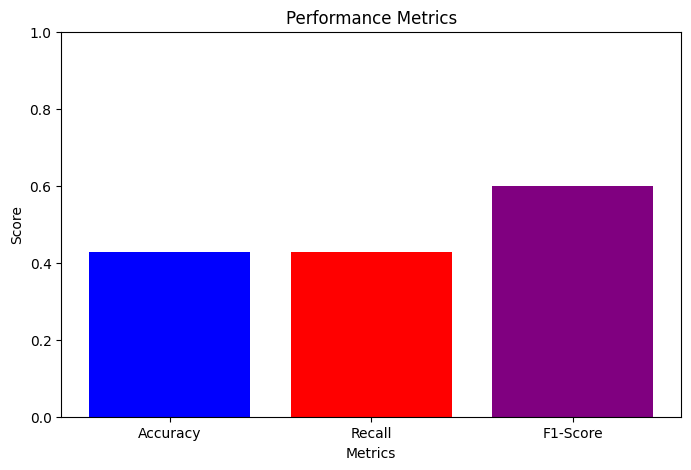

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the performance metrics as a bar chart
def plot_metrics(accuracy, precision, recall, f1):
    metrics = {'Accuracy': accuracy,  'Recall': recall, 'F1-Score': f1}
    metric_names = list(metrics.keys())
    metric_values = list(metrics.values())

    plt.figure(figsize=(8, 5))
    plt.bar(metric_names, metric_values, color=['blue', 'red', 'purple'])
    plt.ylim(0, 1)
    plt.xlabel('Metrics')
    plt.ylabel('Score')
    plt.title('Performance Metrics')
    plt.show()

# Example usage to plot
plot_metrics(accuracy, precision, recall, f1)


Improving the caption using T5 model


In [ ]:
import torch
from transformers import T5Tokenizer, T5ForConditionalGeneration

# Load T5 model and tokenizer
model_name = "t5-large"  # Try "t5-base" if you want a bit more accuracy
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


T5ForConditionalGeneration(
  (shared): Embedding(32128, 1024)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 1024)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=1024, out_features=1024, bias=False)
              (k): Linear(in_features=1024, out_features=1024, bias=False)
              (v): Linear(in_features=1024, out_features=1024, bias=False)
              (o): Linear(in_features=1024, out_features=1024, bias=False)
              (relative_attention_bias): Embedding(32, 16)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseActDense(
              (wi): Linear(in_features=1024, out_features=4096, bias=False)
              (wo): Linear(in_features=4096, out_features=1024, bias=False)
              (d

In [ ]:
# Function to summarize a sentence
def summarize(sentence, max_length=18):
    # Prefix the input sentence with "summarize:"

    input_text = "summarize: " + sentence
    inputs = tokenizer.encode(input_text, return_tensors="pt", max_length=512, truncation=True).to(device)

    # Generate summary
    summary_ids = model.generate(inputs, max_length=max_length, num_beams=4, early_stopping=True)
    summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    return summary

In [ ]:

long_sentence = captions_list[162]
print("Original:", long_sentence)
print("Summarized:", summarize(long_sentence),"\n","\n")

long_sentence = captions_list[496]
print("Original:", long_sentence)
print("Summarized:", summarize(long_sentence),"\n","\n")

long_sentence = captions_list[168]
print("Original:", long_sentence)
print("Summarized:", summarize(long_sentence),"\n","\n")

Original: A street light with many signs on it stands to the foreground of a large building standing beside a naked tree.  
Summarized: street light with many signs stands to the foreground of a large building standing 
 

Original: A woman in a wedding dress standing in a field near a corn farm and holding the bridle of a cream colored horse.
Summarized: a woman in a wedding dress standing in a field near a corn 
 

Original: Close up of a traffic light with three lights, the top illuminated red with a person image, the second down not illuminated, and the bottom on hanging down.
Summarized: traffic light with three lights, the top illuminated red with a person image, 
 



In [ ]:
import numpy as np
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_true = []  # Actual values (1 for match, 0 for no match)
y_pred = []
nums = 0.4730
def evaluate_metrics(f):
    for i in range(499):

        # Assuming the captions are "true" if their similarity is above the threshold
        y_pred.append(1 if similarities_list[i] >= nums else 0)
        # Set ground truth (1 for match, 0 for no match) - this depends on your dataset, adjust accordingly
        y_true.append(1)
        # print(similarities_list[i])
        # print(y_true[i],y_pred[i])

    # Calculate performance metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # Print results
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    return accuracy, precision, recall, f1

accuracy, precision, recall, f1= evaluate_metrics(f)

Accuracy: 0.4289
Precision: 1.0000
Recall: 0.4289
F1 Score: 0.6003


Metrics Table:
            Accuracy  Recall  F1 Score
Old Values    0.4269  0.4269    0.5983


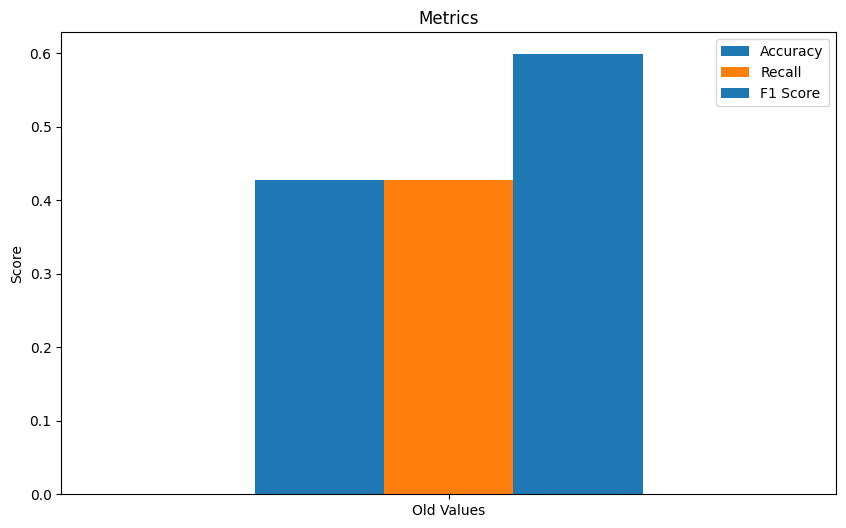

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Given metrics
metrics = {
    "Accuracy": [0.4269],
    "Recall": [0.4269],
    "F1 Score": [0.5983],
}

# Create DataFrame for tabular display
metrics_df = pd.DataFrame(metrics, index=["Old Values"])

# Print the DataFrame as a formatted table
print("Metrics Table:")
print(metrics_df)

# Plotting bar graphs for each metric
metrics_df.plot(kind="bar", figsize=(10, 6), color=["#1f77b4", "#ff7f0e"])
plt.title("Metrics")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="best")
plt.show()
